In [1]:
# 7-15-2026

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import shap

In [3]:
# same architecture as v4 training notebook, needed to load state dict correctly
class ModularEncoder(nn.Module):
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=3, dropout=0.2):
        super().__init__()
        self.atmospheric_idx = atmospheric_idx
        self.ground_idx = ground_idx
        self.fire_idx = fire_idx

        self.atmospheric_branch = self._make_branch(len(atmospheric_idx), branch_embed_dim, dropout)
        self.ground_branch = self._make_branch(len(ground_idx), branch_embed_dim, dropout)
        self.fire_branch = self._make_branch(len(fire_idx), branch_embed_dim, dropout)

    def _make_branch(self, input_dim, embed_dim, dropout): # private
        return nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, embed_dim)
        ) # one branch, now input-32-32-3

    def forward(self, x):
        x_atm = x[:, self.atmospheric_idx]
        x_ground = x[:, self.ground_idx]
        x_fire = x[:, self.fire_idx]

        e_atm = self.atmospheric_branch(x_atm)
        e_ground = self.ground_branch(x_ground)
        e_fire = self.fire_branch(x_fire)

        return torch.cat([e_atm, e_ground, e_fire], dim=-1)

class BiasHead(nn.Module):
    # takes full 33 dim descriptor
    # outputs src bias and tgt bias
    def __init__(self, input_dim=33, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        out = self.net(x)
        src_bias = out[:, 0]
        tgt_bias = out[:, 1]
        return src_bias, tgt_bias

class TransferModelV4(nn.Module):
    # two independent pathways per domain, no shared weights or inputs
    # head has no learned params, its a fixed formula on cached per domain outputs
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=3):
        super().__init__()
        self.encoder = ModularEncoder(atmospheric_idx, ground_idx, fire_idx, branch_embed_dim)
        self.bias_head = BiasHead(input_dim=33)

    def encode(self, x):
        # run once per domain, gives everything needed for any pair this domain shows up in
        e = self.encoder(x)
        src_bias, tgt_bias = self.bias_head(x)
        return e, src_bias, tgt_bias

    def forward(self, desc_i, desc_j):
        # desc_i plays source role, desc_j plays target role for this pair
        e_i, src_bias_i, _ = self.encode(desc_i)
        e_j, _, tgt_bias_j = self.encode(desc_j)

        dist_sq = ((e_i - e_j) ** 2).sum(dim=-1)
        pred = -dist_sq + src_bias_i + tgt_bias_j
        return pred, src_bias_i, tgt_bias_j

In [4]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [5]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)
descriptors.head()

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
domain_id,,,,,,,,,,,,,,,,,,,,,
0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,0.641714,...,0.479085,547.38410,1932.2546,1112.03370,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,0.796118,...,0.499585,338.66165,1157.0903,705.89197,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,0.242577,...,0.257699,3360.49340,8181.0723,8625.16300,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,0.550528,...,0.411259,328.76685,739.6544,901.44635,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,0.315671,...,0.447848,669.05206,2307.7700,1315.65490,0.185203,1.571907,0.090595,0.007227,0.615066,5


In [6]:
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

# same holdout split used in training, needed to refit scaler the same way
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [8]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90",
                     "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90",
               "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90",
             "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]

atmospheric_idx = [desc_scaled.columns.get_loc(c) for c in atmospheric_cols]
ground_idx = [desc_scaled.columns.get_loc(c) for c in ground_cols]
fire_idx = [desc_scaled.columns.get_loc(c) for c in fire_cols]

In [9]:
device = torch.device("cpu")
model = TransferModelV4(atmospheric_idx, ground_idx, fire_idx).to(device)
model.load_state_dict(torch.load("../training/transfer_model_v4.pt", map_location=device))
model.eval()  # turn of dropout so shap gets determiinstic outputs

TransferModelV4(
  (encoder): ModularEncoder(
    (atmospheric_branch): Sequential(
      (0): Linear(in_features=12, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=32, out_features=3, bias=True)
    )
    (ground_branch): Sequential(
      (0): Linear(in_features=10, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=32, out_features=3, bias=True)
    )
    (fire_branch): Sequential(
      (0): Linear(in_features=11, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace

In [10]:
# all ordered pairs including diagonal, this is the background set for shap
all_pairs = [(i, j) for i in active_ids for j in active_ids]

# concat desc_i and desc_j into one 66-dim row per pair
background_rows = []
for i, j in all_pairs:
    row = np.concatenate([desc_scaled.loc[i].values, desc_scaled.loc[j].values])
    background_rows.append(row)

background_data = np.array(background_rows, dtype=np.float32)

In [11]:
background_data.shape

(1156, 66)

In [12]:
class WrappedModel(nn.Module):
    def __init__(self, model, input_dim=33):
        super().__init__()
        self.model = model
        self.input_dim = input_dim

    def forward(self, x):
        # first 33 cols are desc_i, next 33 are desc_j
        desc_i = x[:, :self.input_dim]
        desc_j = x[:, self.input_dim:]
        pred, src_bias_i, tgt_bias_j = self.model(desc_i, desc_j)
        return pred.unsqueeze(-1)  # shap wants (batch, 1), not flat (batch,)


wrapped_model = WrappedModel(model)
wrapped_model.eval()

WrappedModel(
  (model): TransferModelV4(
    (encoder): ModularEncoder(
      (atmospheric_branch): Sequential(
        (0): Linear(in_features=12, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=32, out_features=32, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.2, inplace=False)
        (6): Linear(in_features=32, out_features=3, bias=True)
      )
      (ground_branch): Sequential(
        (0): Linear(in_features=10, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=32, out_features=32, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.2, inplace=False)
        (6): Linear(in_features=32, out_features=3, bias=True)
      )
      (fire_branch): Sequential(
        (0): Linear(in_features=11, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=32, out_fe

In [13]:
# wrapped output should exactly match original model output
background_tensor = torch.tensor(background_data, dtype=torch.float32)

In [14]:
with torch.no_grad():
    original_preds, _, _ = model(background_tensor[:, :33], background_tensor[:, 33:])
    wrapped_preds = wrapped_model(background_tensor)

In [15]:
with torch.no_grad():
    wrapped_preds = wrapped_model(background_tensor)
print(wrapped_preds.shape)  # should be (1156, 1)

torch.Size([1156, 1])


In [16]:
import copy

def strip_dropout(module):
    # swap every dropout layer for identity, since eval mode makes it a no-op anyway
    # this just removes the op shap trips on
    for name, child in module.named_children():
        if isinstance(child, nn.Dropout):
            setattr(module, name, nn.Identity())
        else:
            strip_dropout(child)
    return module

shap_model = copy.deepcopy(model)
strip_dropout(shap_model)
shap_model.eval()

print(shap_model)

TransferModelV4(
  (encoder): ModularEncoder(
    (atmospheric_branch): Sequential(
      (0): Linear(in_features=12, out_features=32, bias=True)
      (1): ReLU()
      (2): Identity()
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Identity()
      (6): Linear(in_features=32, out_features=3, bias=True)
    )
    (ground_branch): Sequential(
      (0): Linear(in_features=10, out_features=32, bias=True)
      (1): ReLU()
      (2): Identity()
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Identity()
      (6): Linear(in_features=32, out_features=3, bias=True)
    )
    (fire_branch): Sequential(
      (0): Linear(in_features=11, out_features=32, bias=True)
      (1): ReLU()
      (2): Identity()
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Identity()
      (6): Linear(in_features=32, out_features=3, bias=True)
    )
  )
  (bias_head): BiasHead(
    (net):

In [17]:
wrapped_model = WrappedModel(shap_model)
wrapped_model.eval()

explainer = shap.DeepExplainer(wrapped_model, background_tensor)

shap_values = explainer.shap_values(background_tensor, check_additivity=False)
print(np.array(shap_values).shape)
# good, outputted correct shape

(1156, 66, 1)


In [18]:
sv = np.array(shap_values)
sv = sv.squeeze(-1)  # drop trailing output dim, now (1156, 66)
print(sv.shape)  # should be (1156, 66)

(1156, 66)


In [19]:
# src = domain i (source), tgt = domain j (target)
desc_cols = descriptors_active.columns.tolist()
feature_names = [f"src_{c}" for c in desc_cols] + [f"tgt_{c}" for c in desc_cols]

mean_abs_shap = np.abs(sv).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(20))

                     feature  mean_abs_shap
60     tgt_cams_frpfire_mean       0.005808
40           tgt_t2m_max_std       0.005275
52             tgt_swvl1_std       0.003886
61      tgt_cams_frpfire_std       0.003817
64  tgt_land_cover_diversity       0.003651
28      src_cams_frpfire_std       0.003537
54            tgt_swvl4_mean       0.003445
47                tgt_tp_p90       0.003409
7            src_t2m_max_std       0.003333
27     src_cams_frpfire_mean       0.003125
41           tgt_t2m_max_p90       0.003051
34               tgt_vpd_std       0.002989
35               tgt_vpd_p90       0.002795
62      tgt_cams_frpfire_p90       0.002710
50          tgt_fwi_mean_p90       0.002659
57          tgt_gwis_ba_mean       0.002658
49          tgt_fwi_mean_std       0.002649
58           tgt_gwis_ba_std       0.002597
10              src_ndvi_std       0.002565
55             tgt_swvl4_std       0.002503


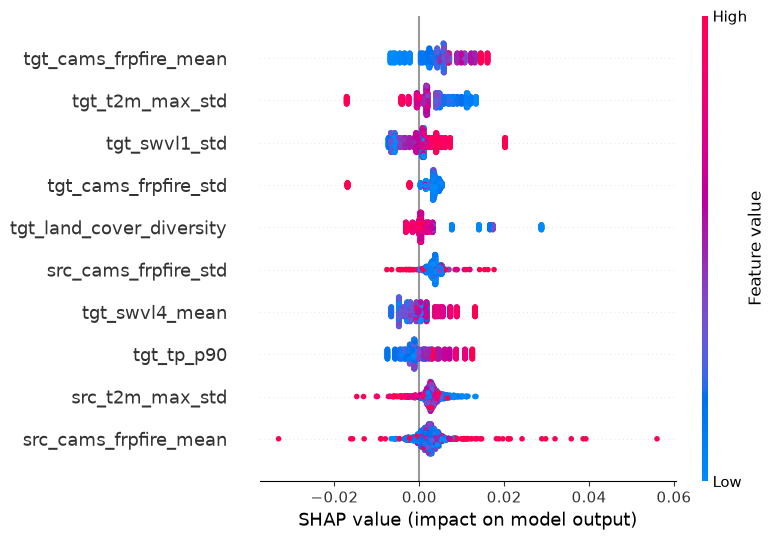

In [20]:
import matplotlib.pyplot as plt

shap.summary_plot(sv, background_data, feature_names=feature_names, show=False, max_display=10)
plt.tight_layout()
plt.show()

In [21]:
# grab every feature name ending in std, both src and tgt sides
std_features = [f for f in feature_names if f.endswith("std")]

for f in std_features:
    idx = feature_names.index(f)
    corr = np.corrcoef(background_data[:, idx], sv[:, idx])[0, 1]
    print(f"{f}: {corr:.3f}")

src_vpd_std: -0.522
src_ws10_std: -0.379
src_t2m_max_std: -0.484
src_ndvi_std: 0.863
src_tp_std: 0.768
src_fwi_mean_std: -0.727
src_swvl1_std: 0.468
src_swvl4_std: -0.227
src_gwis_ba_std: 0.128
src_cams_frpfire_std: -0.129
tgt_vpd_std: -0.648
tgt_ws10_std: -0.501
tgt_t2m_max_std: -0.883
tgt_ndvi_std: 0.049
tgt_tp_std: -0.427
tgt_fwi_mean_std: 0.337
tgt_swvl1_std: 0.793
tgt_swvl4_std: 0.517
tgt_gwis_ba_std: 0.617
tgt_cams_frpfire_std: -0.742


In [22]:
base_vars = []
for f in feature_names:
    if f.endswith("std"):
        var = f.replace("src_", "").replace("tgt_", "")
        if var not in base_vars:
            base_vars.append(var)

for var in base_vars:
    src_idx = feature_names.index(f"src_{var}")
    tgt_idx = feature_names.index(f"tgt_{var}")
    src_corr = np.corrcoef(background_data[:, src_idx], sv[:, src_idx])[0, 1]
    tgt_corr = np.corrcoef(background_data[:, tgt_idx], sv[:, tgt_idx])[0, 1]
    print(f"{var}: src {src_corr:.3f}, tgt {tgt_corr:.3f}")

vpd_std: src -0.522, tgt -0.648
ws10_std: src -0.379, tgt -0.501
t2m_max_std: src -0.484, tgt -0.883
ndvi_std: src 0.863, tgt 0.049
tp_std: src 0.768, tgt -0.427
fwi_mean_std: src -0.727, tgt 0.337
swvl1_std: src 0.468, tgt 0.793
swvl4_std: src -0.227, tgt 0.517
gwis_ba_std: src 0.128, tgt 0.617
cams_frpfire_std: src -0.129, tgt -0.742


In [23]:
# 7-17-2026 - shap analysis for encoder and bias networks individually

In [24]:
# per domain input, not per pair, since encoder and bias head each take one domain's descriptor
domain_tensor = torch.tensor(desc_scaled.loc[active_ids].values, dtype=torch.float32)
desc_cols = descriptors_active.columns.tolist()

In [25]:
class EncoderWrapper(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, x):
        return self.encoder(x)


class BiasWrapper(nn.Module):
    def __init__(self, bias_head):
        super().__init__()
        self.bias_head = bias_head

    def forward(self, x):
        src_bias, tgt_bias = self.bias_head(x)
        return torch.stack([src_bias, tgt_bias], dim=-1)

In [26]:
# strip dropout same way as before, deepcopy each submodule separately
encoder_clean = copy.deepcopy(model.encoder)
strip_dropout(encoder_clean)
encoder_clean.eval()

bias_clean = copy.deepcopy(model.bias_head)
strip_dropout(bias_clean)
bias_clean.eval()

encoder_wrapped = EncoderWrapper(encoder_clean)
bias_wrapped = BiasWrapper(bias_clean)

In [27]:
# encoder shap
explainer_enc = shap.DeepExplainer(encoder_wrapped, domain_tensor)
sv_enc = explainer_enc.shap_values(domain_tensor, check_additivity=False)
sv_enc = np.array(sv_enc)
print(sv_enc.shape)  # should b (34, 33, 9)

(34, 33, 9)


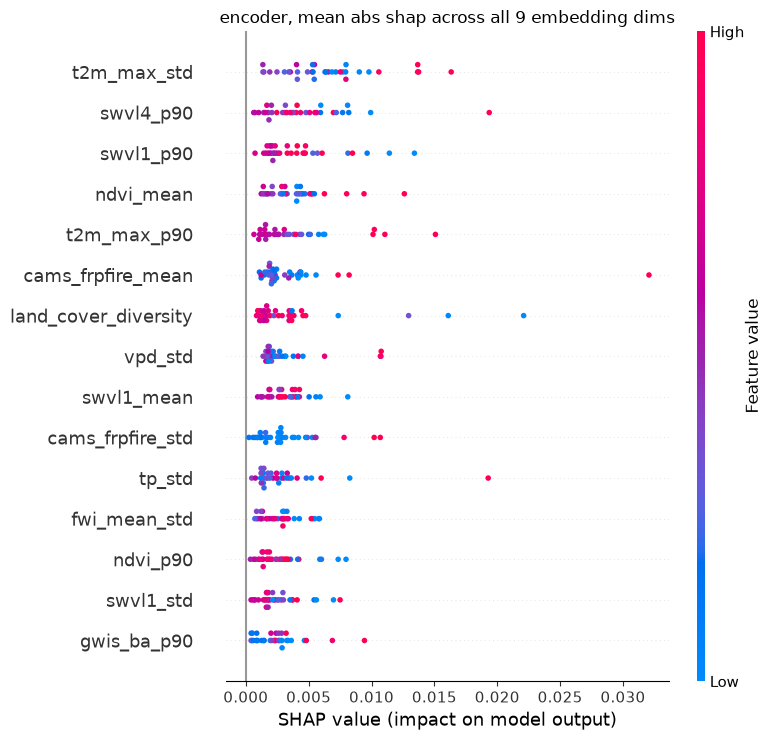

In [28]:
# collapse across the 9 embedding dims, mean abs so branch dims dont cancel each other
sv_enc_agg = np.abs(sv_enc).mean(axis=-1)  # (34, 33)

shap.summary_plot(sv_enc_agg, domain_tensor.numpy(), feature_names=desc_cols, show=False, max_display=15)
plt.title("encoder, mean abs shap across all 9 embedding dims")
plt.tight_layout()
plt.show()

In [29]:
# bias head shap
explainer_bias = shap.DeepExplainer(bias_wrapped, domain_tensor)
sv_bias = explainer_bias.shap_values(domain_tensor, check_additivity=False)
sv_bias = np.array(sv_bias)
print(sv_bias.shape)  # should be (34, 33, 2)

(34, 33, 2)


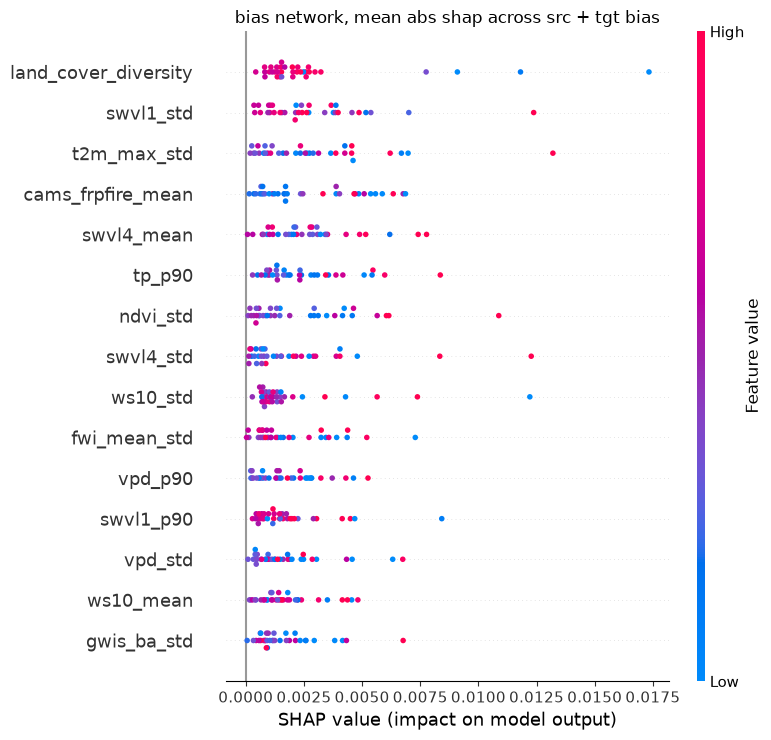

In [30]:
sv_bias_agg = np.abs(sv_bias).mean(axis=-1)  # (34, 33)

shap.summary_plot(sv_bias_agg, domain_tensor.numpy(), feature_names=desc_cols, show=False, max_display=15)
plt.title("bias network, mean abs shap across src + tgt bias")
plt.tight_layout()
plt.show()

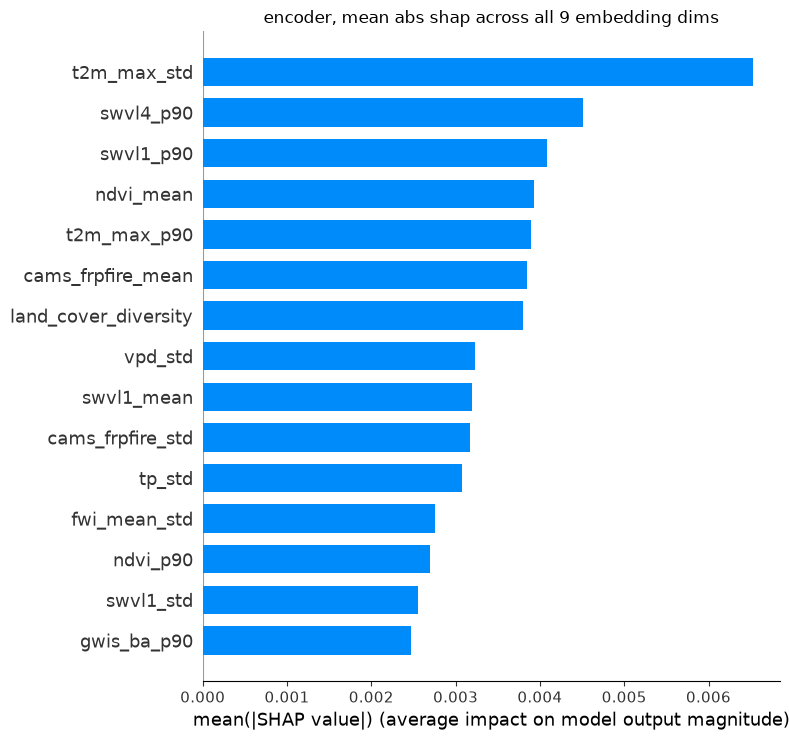

In [31]:
shap.summary_plot(sv_enc_agg, domain_tensor.numpy(), feature_names=desc_cols,
                   plot_type="bar", show=False, max_display=15)
plt.title("encoder, mean abs shap across all 9 embedding dims")
plt.tight_layout()
plt.show()

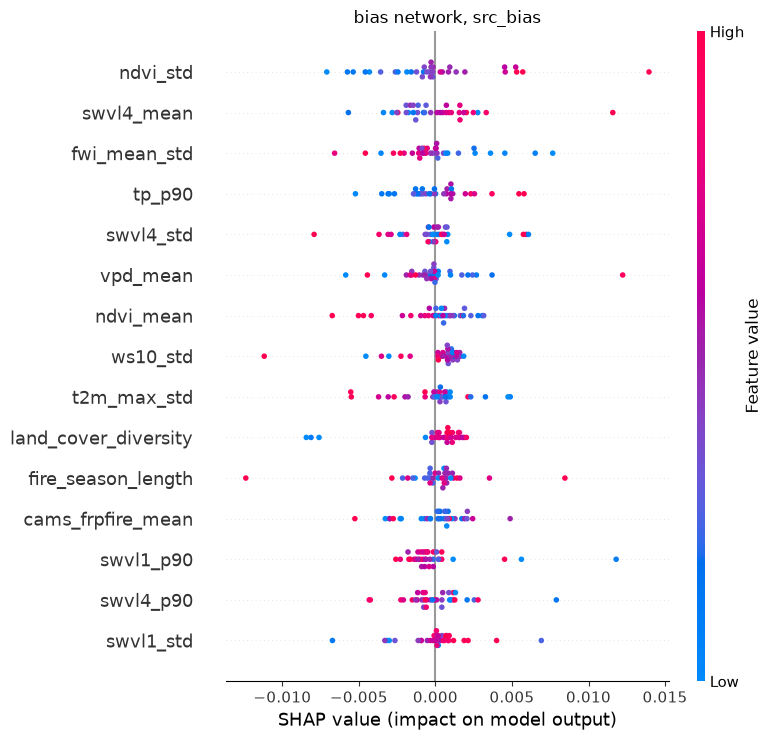

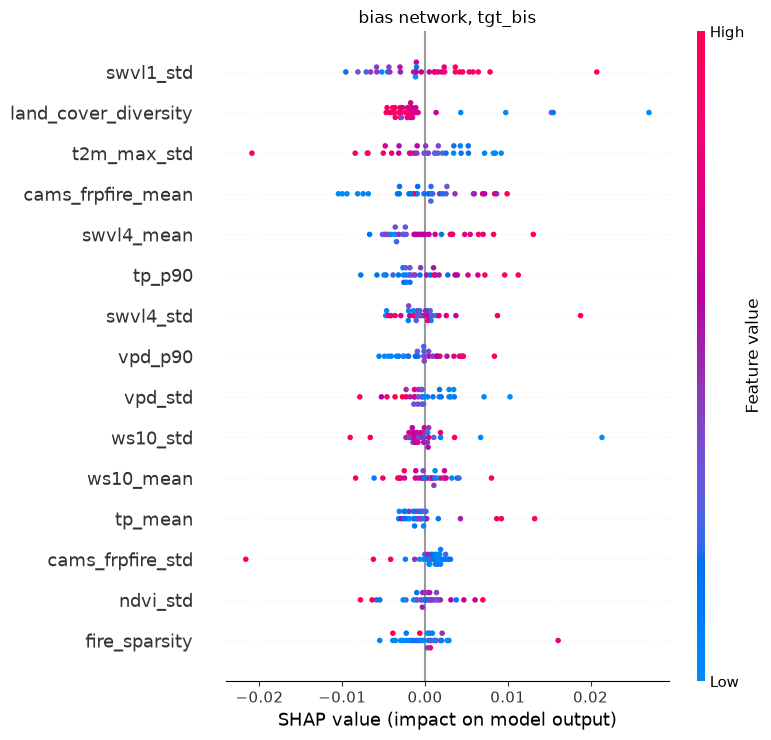

In [ ]:
sv_src = sv_bias[:, :, 0]
sv_tgt = sv_bias[:, :, 1]

shap.summary_plot(sv_src, domain_tensor.numpy(), feature_names=desc_cols, show=False, max_display=15)
plt.title("bias network, src_bias")
plt.tight_layout()
plt.show()

shap.summary_plot(sv_tgt, domain_tensor.numpy(), feature_names=desc_cols, show=False, max_display=15)
plt.title("bias network, tgt_bis")
plt.tight_layout()
plt.show()